# Import libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# Define artificial dataset functions

In [2]:
def moons_dataset(n_samples):
    """Creates a dataset of two distinct interleaving half circles"""
    noise_scale = 5
    x1_f1 = np.linspace(10, 60, n_samples)
    f1 = -0.04 * (x1_f1 - 35)**2 + 80 + np.random.normal(0, noise_scale, n_samples)
    x1_f2 = np.linspace(40, 90, n_samples)
    f2 = 0.04 * (x1_f2 - 65)**2 + 20 + np.random.normal(0, noise_scale, n_samples)

    x1_all = np.concatenate([x1_f1, x1_f2])
    x2_all = np.concatenate([f1, f2])

    dataset = pd.DataFrame({
        "x1": x1_all,
        "x2": x2_all
    })
    return dataset

def two_normals_dataset(n_samples):
    """Creates two normal distributed population"""
    x1 = np.random.normal(loc=30, scale=8, size=n_samples)
    x2 = np.random.normal(loc=70, scale=8, size=n_samples)
    y1 = np.random.normal(loc=40, scale=8, size=n_samples)
    y2 = np.random.normal(loc=75, scale=8, size=n_samples)

    x1_all = np.concatenate([x1, x2])
    x2_all = np.concatenate([y1,y2])

    dataset = pd.DataFrame({
        "x1": x1_all,
        "x2": x2_all
    })
    return dataset

def circles_dataset(n_samples):
    """Creates two hollow circles that have the same center"""
    up_radius = 40
    lo_radius = 20
    center = (40, 40)
    noise_scale = 2

    n_per_circle = n_samples // 2
    theta = np.linspace(0, 2 * np.pi, n_per_circle)

    x1_outer = center[0] + up_radius * np.cos(theta) + np.random.normal(0, noise_scale, n_per_circle)
    x2_outer = center[1] + up_radius * np.sin(theta) + np.random.normal(0, noise_scale, n_per_circle)
    x1_inner = center[0] + lo_radius * np.cos(theta) + np.random.normal(0, noise_scale, n_per_circle)
    x2_inner = center[1] + lo_radius * np.sin(theta) + np.random.normal(0, noise_scale, n_per_circle)

    x1_all = np.concatenate([x1_outer, x1_inner])
    x2_all = np.concatenate([x2_outer, x2_inner])

    dataset = pd.DataFrame({
        "x1": x1_all,
        "x2": x2_all
    })
    return dataset

dataset_functions = [moons_dataset, two_normals_dataset, circles_dataset]

# Model

In [6]:
class NeighbourClusterer:
    def __init__(self, n_neighbors=5, splitting_z_score=3,color_palette="viridis"):
        self.n_neighbors = n_neighbors
        self.splitting_z_score = splitting_z_score
        self.color_palette = color_palette

    def fit(self, df):
        # initializing
        dataset = df.copy()
        gr = nx.Graph()

        # create nodes
        gr.add_nodes_from(dataset.index)

        nn_model = NearestNeighbors(n_neighbors=self.n_neighbors)
        nn_model.fit(dataset)
        distances, indices = nn_model.kneighbors(dataset)

        # create edges to nearest neighbours
        idx_mapper = dataset.index.tolist()

        for i, neighbors_list in enumerate(indices):
            node_id = idx_mapper[i]
            for j, neighbor_pos in enumerate(neighbors_list):
                if j > 0:
                    neighbor_id = idx_mapper[neighbor_pos]
                    weight = distances[i][j]
                    gr.add_edge(node_id, neighbor_id, weight=weight)

        # destroy overlong edges
        weights = [d.get('weight', 0) for u, v, d in gr.edges(data=True)]
        mean = sum(weights) / len(weights)
        variance = sum((x - mean) ** 2 for x in weights) / (len(weights) - 1)
        std = variance ** 0.5

        removed_edges = []
        for u, v, d in gr.edges(data=True):
            weight = d.get('weight', 0)
            z_score = (weight - mean) / std

            if z_score > self.splitting_z_score:
                removed_edges.append((u, v))

        gr.remove_edges_from(removed_edges)

        # create class column and assign classes
        connected_components = list(nx.connected_components(gr))
        dataset["cls"] = -1

        for i, component in enumerate(connected_components):
            dataset.loc[list(component), "cls"] = (i + 1)

        return dataset
    def plot(self, df):
        plt.figure(figsize=(12, 8))
        unique_cls = sorted(df["cls"].unique())
        colors = plt.get_cmap(self.color_palette, len(unique_cls))

        for i, cls_name in enumerate(unique_cls):
            subset = df[df["cls"] == cls_name]
            plt.scatter(
                subset["x1"],
                subset["x2"],
                color=colors(i),
                label=f"Class {cls_name}",
                alpha=0.7
            )

        plt.legend(title="Classes")
    def plot_twin(self,classed_df, original_df,figsize=(12,5)):
        # Create two subplots side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

        # original_df plot:
        ax1.scatter(original_df["x1"], original_df["x2"], alpha=0.7)
        ax1.set_title("Original Dataset")

        # classed_df plot:
        unique_cls = sorted(classed_df["cls"].unique())
        colors = plt.get_cmap(self.color_palette, len(unique_cls))
        for i, cls_name in enumerate(unique_cls):
            subset = classed_df[classed_df["cls"] == cls_name]
            ax2.scatter(
                subset["x1"],
                subset["x2"],
                color=colors(i),
                label=f"Class {cls_name}",
                alpha=0.7
            )
        ax2.set_title("Clustered Dataset")
        ax2.legend(title="Classes")

# Create dataset

In [ ]:
df = moons_dataset(300)
df.head()

In [ ]:
plt.scatter(df["x1"],df["x2"])

# Execute the model and observe the output

In [ ]:
n_clusterer = NeighbourClusterer()
classed_df = n_clusterer.fit(df)
classed_df.head()

In [ ]:
classed_df["cls"].value_counts()

In [ ]:
n_clusterer.plot(classed_df)

# Other datasets and results

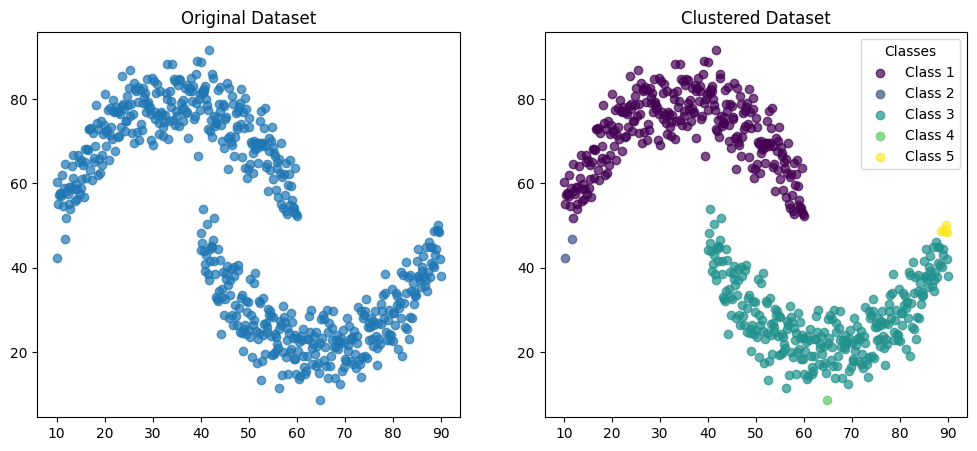

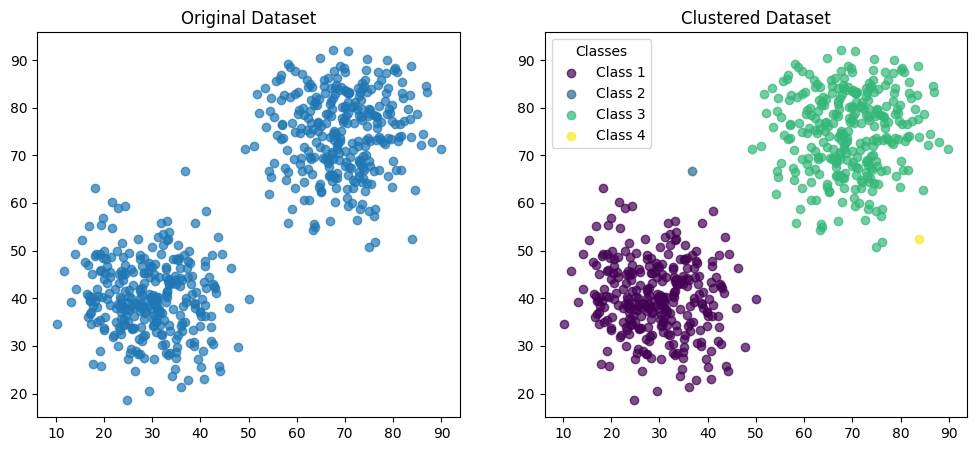

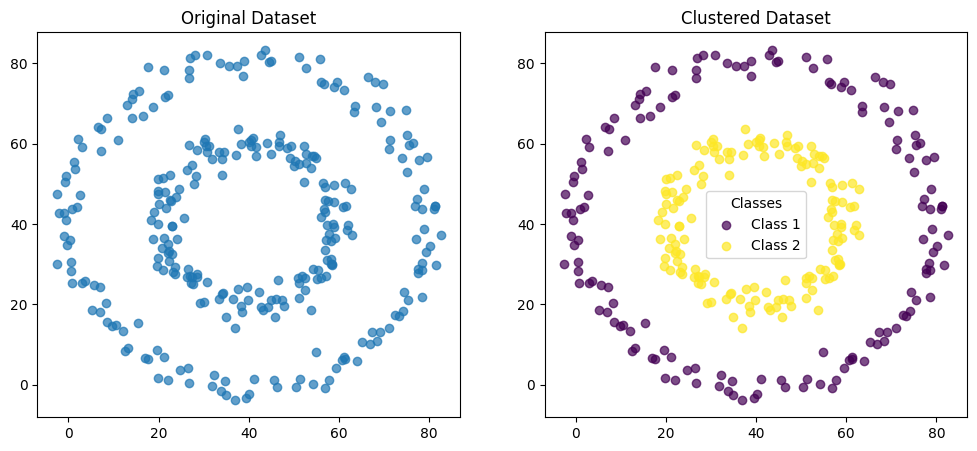

In [7]:
for dataset_function in dataset_functions:
    df = dataset_function(300)
    n_clusterer = NeighbourClusterer()
    classed_df = n_clusterer.fit(df)
    n_clusterer.plot_twin(classed_df, df)